# Assignment 1
# Predicting Customer Churn Using Decision Trees and Random Forests
### SOEN 471 Big Data Analysis
### Winter 2026
### Elizabeth Wong (Student ID: 40282463)
### Matthieu Geahel (Student ID: 29389601)
### Ranjit Singh Dhunna (Student ID: 40294791)

Please note that random_state=42 is implemented in this notebook for reproducibility.

In [29]:
# import relevant python libraries

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

## Task 1 Data Preparation and Exploration (EDA)
Loads customer_churn.csv, displays structure and summary statistics,
identifies and handles missing values, and performs EDA (histograms,
box plots, correlation analysis). Uses pandas, matplotlib, seaborn.

In [30]:
# Step 1: Load data

print("=" * 60)
print("1. LOAD DATA")
print("=" * 60)
df = pd.read_csv('customer_churn.csv')
print("Dataset loaded successfully.")
print("\nFirst 10 rows:")
print(df.head(10))

1. LOAD DATA
Dataset loaded successfully.

First 10 rows:
   CustomerID  Age  Subscription_Length_Months  Watch_Time_Hours  \
0           1   56                          35        157.957600   
1           2   69                          15         93.515499   
2           3   46                          25         87.095143   
3           4   32                          28        113.986323   
4           5   60                          10        101.534816   
5           6   25                          17        166.093304   
6           7   38                          22         79.929269   
7           8   56                          26        122.738855   
8           9   36                          25        221.841933   
9          10   40                          17        136.522261   

   Number_of_Logins  Payment_Issues  Number_of_Complaints  \
0                59               0                     1   
1                26               0                     3   
2         

In [31]:
# Step 2: Dataset structure

print("\n" + "=" * 60)
print("2. DATASET STRUCTURE")
print("=" * 60)
print("Shape (rows, columns):", df.shape)
print("\nColumn names and dtypes:")
print(df.dtypes)
print("\nInfo (non-null counts and dtypes):")
df.info()


2. DATASET STRUCTURE
Shape (rows, columns): (1000, 12)

Column names and dtypes:
CustomerID                      int64
Age                             int64
Subscription_Length_Months      int64
Watch_Time_Hours              float64
Number_of_Logins                int64
Payment_Issues                  int64
Number_of_Complaints            int64
Resolution_Time_Days            int64
Membership_Type                   str
Payment_Method                    str
Preferred_Content_Type            str
Churn                           int64
dtype: object

Info (non-null counts and dtypes):
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   CustomerID                  1000 non-null   int64  
 1   Age                         1000 non-null   int64  
 2   Subscription_Length_Months  1000 non-null   int64  
 3   Watch_Time_Hours           

In [32]:
# Step 3: Summary statistics

print("\n" + "=" * 60)
print("3. SUMMARY STATISTICS")
print("=" * 60)
print("Numerical summary:")
print(df.describe())
print("\nMembership_Type value counts:")
print(df['Membership_Type'].value_counts())
print("\nPayment_Method value counts:")
print(df['Payment_Method'].value_counts())
print("\nPreferred_Content_Type value counts:")
print(df['Preferred_Content_Type'].value_counts())
print("\nTarget (Churn) distribution:")
print(df['Churn'].value_counts())


3. SUMMARY STATISTICS
Numerical summary:
        CustomerID         Age  Subscription_Length_Months  Watch_Time_Hours  \
count  1000.000000  1000.00000                 1000.000000       1000.000000   
mean    500.500000    43.81900                   18.218000        120.750899   
std     288.819436    14.99103                   10.177822         38.583580   
min       1.000000    18.00000                    1.000000         10.000000   
25%     250.750000    31.00000                    9.000000         93.630672   
50%     500.500000    44.00000                   18.000000        122.085008   
75%     750.250000    56.00000                   27.000000        147.273070   
max    1000.000000    69.00000                   35.000000        227.988566   

       Number_of_Logins  Payment_Issues  Number_of_Complaints  \
count       1000.000000     1000.000000           1000.000000   
mean          30.984000        0.245000              4.552000   
std           17.562237        0.430302   

In [33]:
# Step 4: Identify and handle missing values

print("\n" + "=" * 60)
print("4. MISSING VALUES")
print("=" * 60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
if len(missing_df) == 0:
    print("No missing values found in the dataset.")
else:
    print(missing_df)

if df.isnull().any().any():
    rows_before = len(df)
    df = df.dropna()
    print(f"Dropped {rows_before - len(df)} rows with missing values. Shape now: {df.shape}")
else:
    print("No missing values to handle. Proceeding with full dataset.")

# Save cleansed dataset for downstream use (Tasks 2, 3) and for submission
df.to_csv('customer_churn_cleaned.csv', index=False)
print(f"Saved cleansed data to customer_churn_cleaned.csv ({len(df)} rows, {len(df.columns)} columns).")


4. MISSING VALUES
No missing values found in the dataset.
No missing values to handle. Proceeding with full dataset.
Saved cleansed data to customer_churn_cleaned.csv (1000 rows, 12 columns).


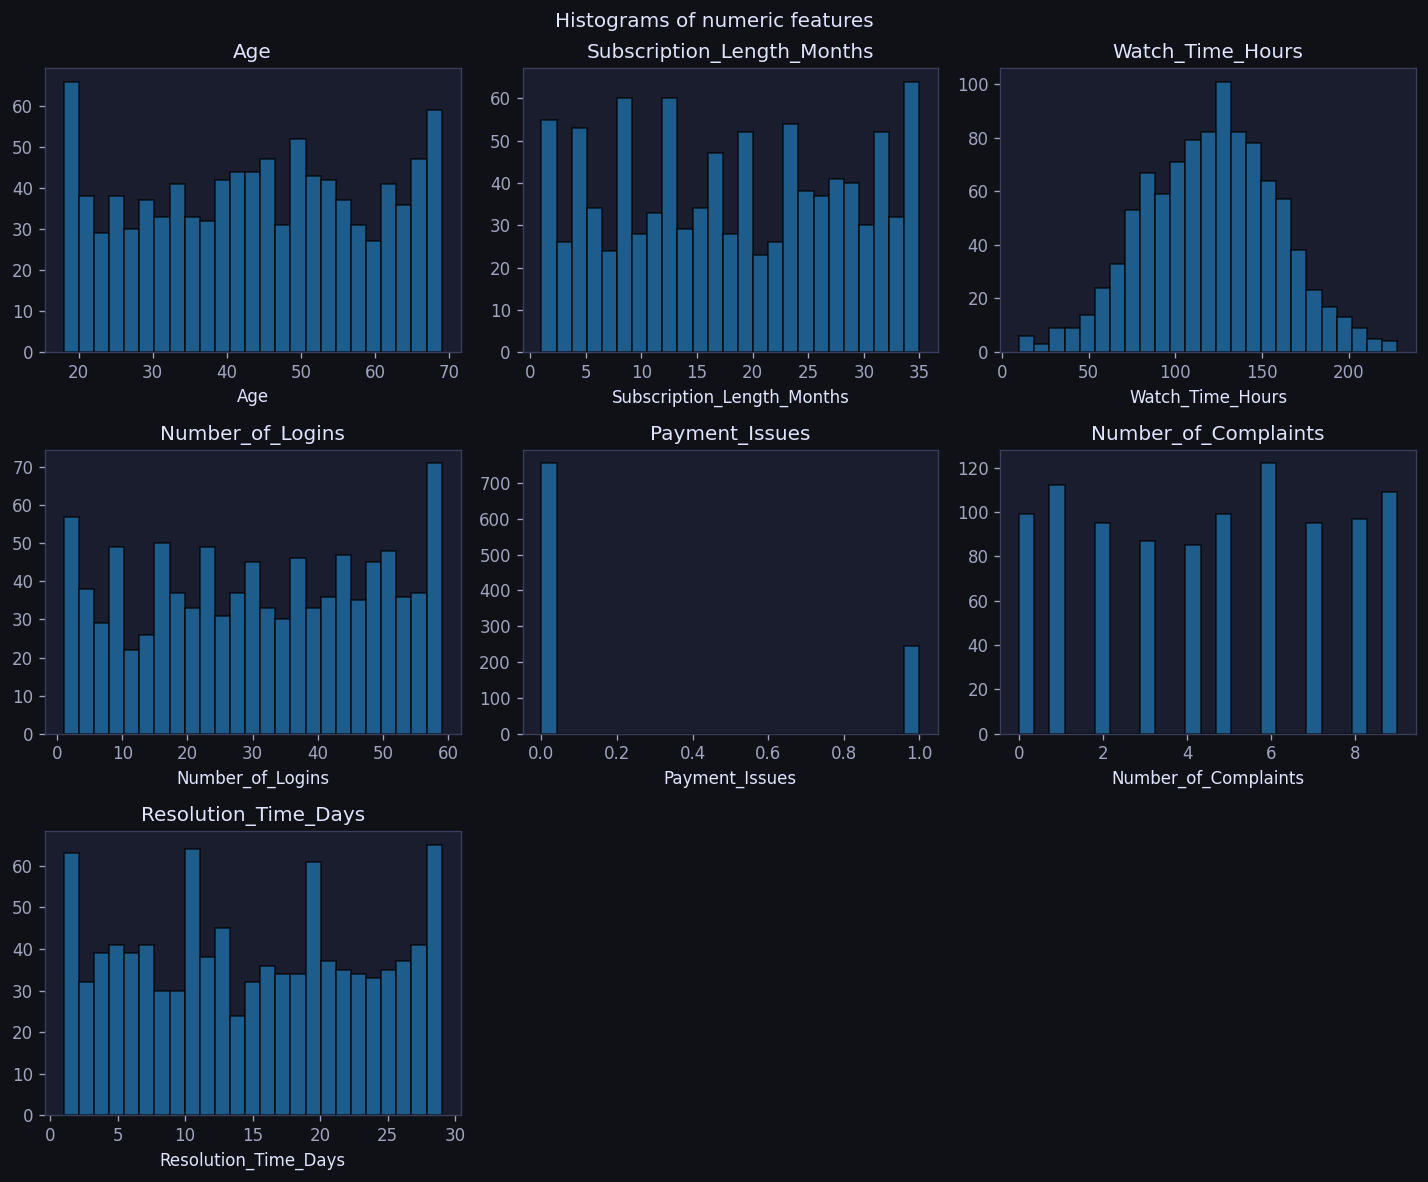


Saved: eda_histograms.png


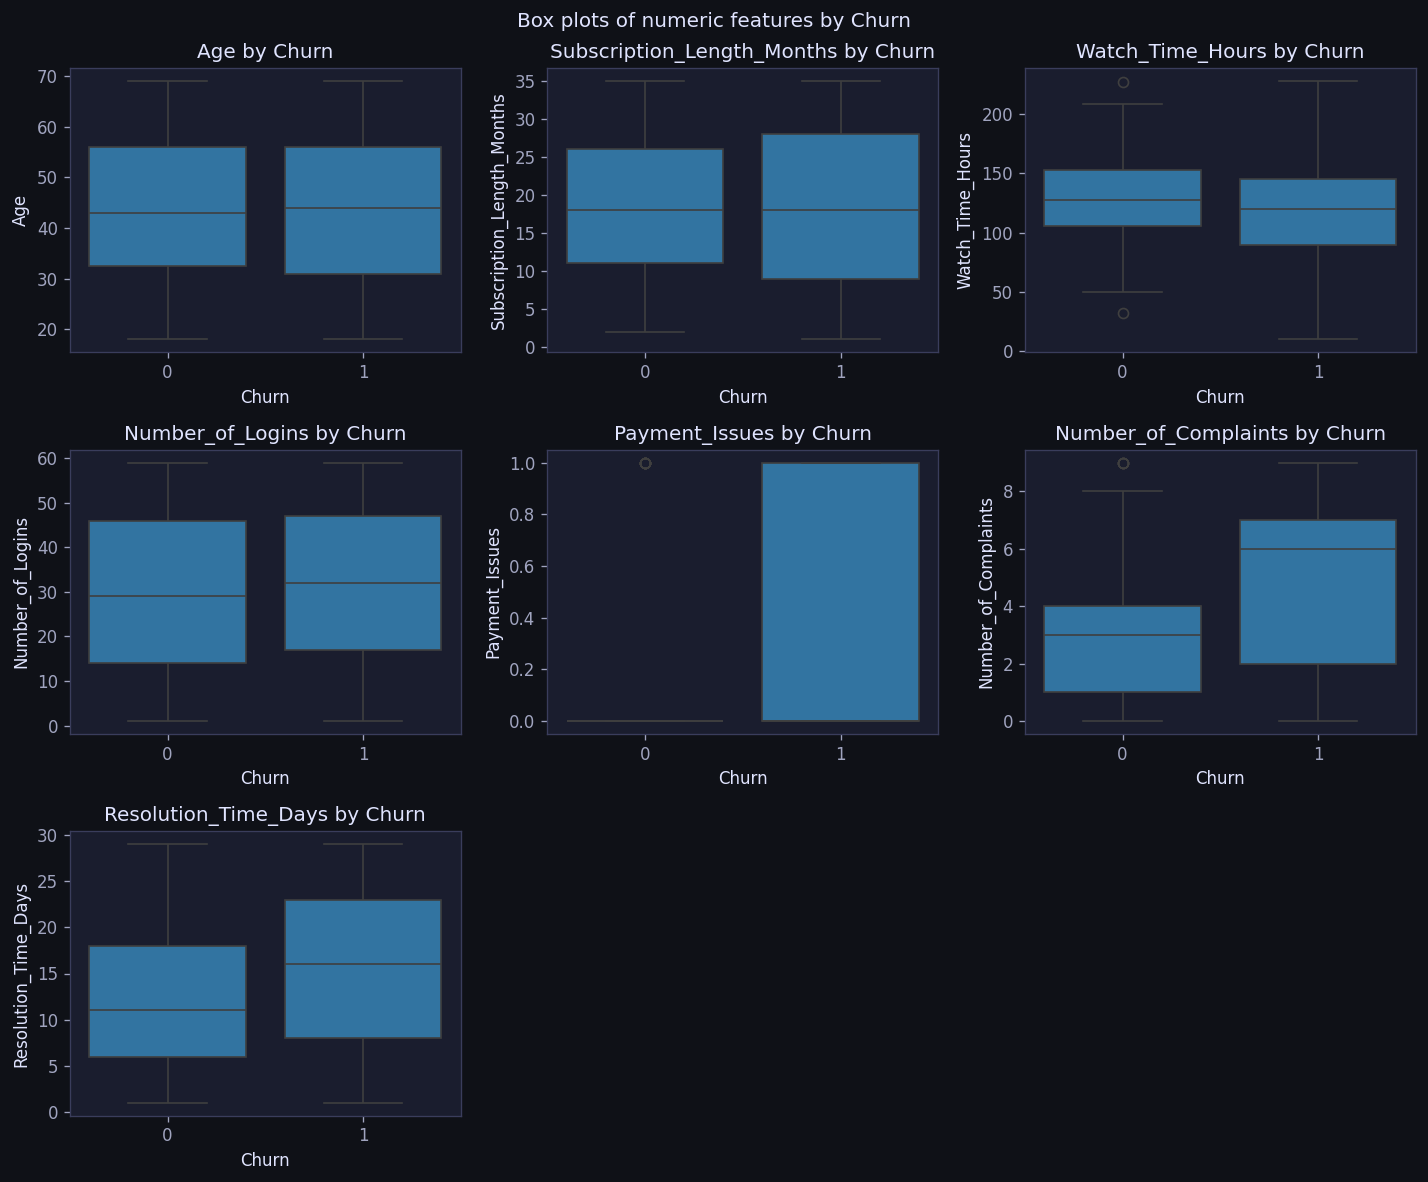

Saved: eda_boxplots.png


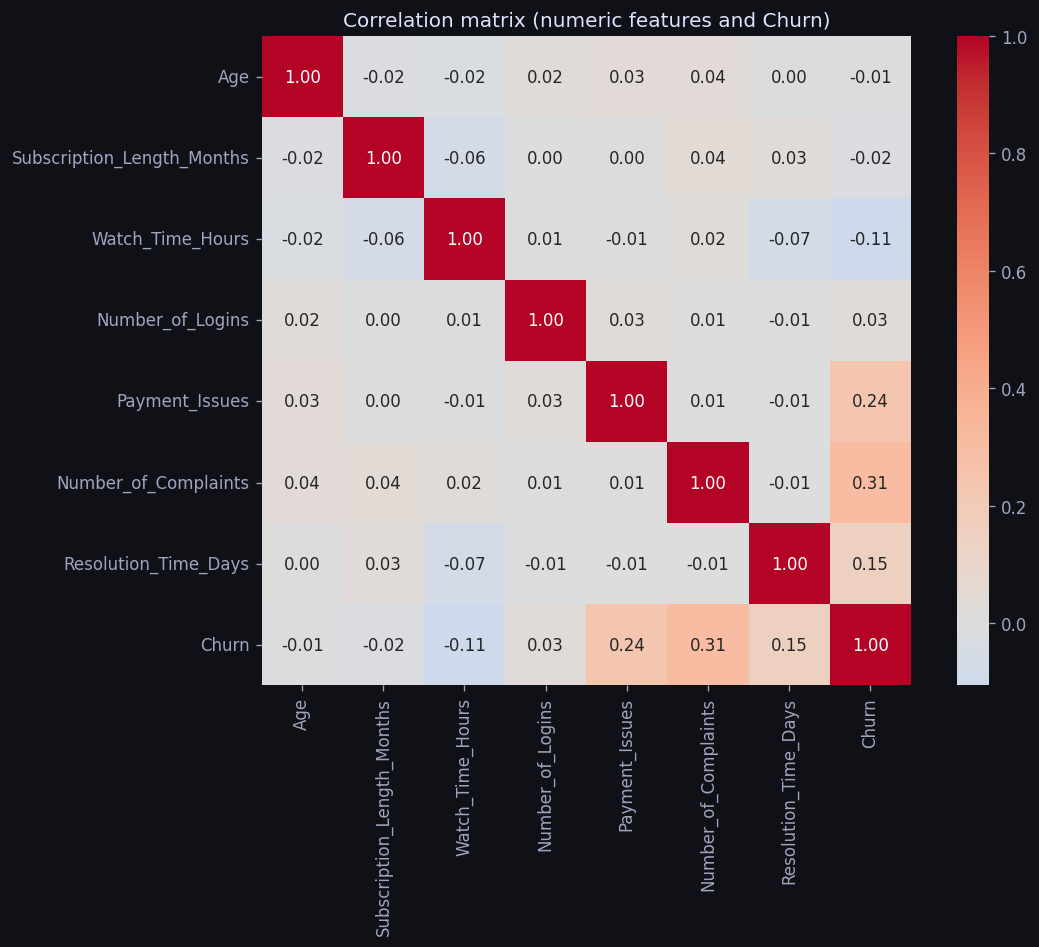

Saved: eda_correlation.png

5. CORRELATION WITH CHURN (target)
Number_of_Complaints          0.310561
Payment_Issues                0.239394
Resolution_Time_Days          0.151335
Number_of_Logins              0.027516
Age                          -0.010949
Subscription_Length_Months   -0.018409
Watch_Time_Hours             -0.105913
Name: Churn, dtype: float64
EDA complete. Figures saved in current directory.


In [34]:
# Step 5 Exploratory data analysis (visualizations)

numeric_cols = [c for c in df.columns if df[c].dtype in ['int64', 'float64']
                and c not in ['CustomerID', 'Churn']]

# Histograms (7 numeric features -> 3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=25, edgecolor='black', alpha=0.7)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
# Hide unused subplots (we have 7 plots, grid has 9)
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Histograms of numeric features', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('eda_histograms.png', dpi=150, bbox_inches='tight')
plt.close()
print("\nSaved: eda_histograms.png")

# Box plots by Churn (7 numeric features -> 3x3 grid)
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Churn', y=col, ax=axes[i])
    axes[i].set_title(col + ' by Churn')
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Box plots of numeric features by Churn', fontsize=12)
plt.tight_layout()
plt.show()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.close()
print("Saved: eda_boxplots.png")

# Correlation matrix
corr_cols = numeric_cols + ['Churn']
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix (numeric features and Churn)')
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: eda_correlation.png")

print("\n" + "=" * 60)
print("5. CORRELATION WITH CHURN (target)")
print("=" * 60)
print(corr['Churn'].drop('Churn').sort_values(ascending=False))

print("EDA complete. Figures saved in current directory.")

#### Step 6 PATTERNS AND ANOMALIES (summary)

- Distributions: Age and Subscription_Length_Months are roughly symmetric;
  Watch_Time_Hours, Number_of_Logins, Resolution_Time_Days show some skew.
  Number_of_Complaints and Payment_Issues are discrete with limited range.
- Churn vs features: Box plots suggest higher Resolution_Time_Days and more
  complaints may be associated with churn; lower watch time or logins may
  also relate to churn (to be tested by models).
- Correlation with Churn: The heatmap shows which numeric features are most
  linearly associated with Churn. Categorical features need encoding for
  modeling.
- Anomalies: Check for impossible values (e.g. negative ages/times). For
  tree/random forest models, extreme outliers typically have limited impact.

## Task 2 Decision Tree Classifier

In [35]:
# settings for visualizations

# Plot styling
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#1a1d2e',
    'axes.edgecolor': '#3a3d5c',
    'axes.labelcolor': '#e0e4ff',
    'text.color': '#e0e4ff',
    'xtick.color': '#a0a4bf',
    'ytick.color': '#a0a4bf',
    'grid.color': '#2a2d4a',
    'grid.alpha': 0.5,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight',
    'savefig.facecolor': '#0f1117',
})

PALETTE = ['#5b6fe6', '#e65b7f']
ACCENT  = '#5b6fe6'
POP     = '#e65b7f'


[1] Loading and inspecting dataset...

  Dataset shape : (1000, 12)
  Columns       : ['CustomerID', 'Age', 'Subscription_Length_Months', 'Watch_Time_Hours', 'Number_of_Logins', 'Payment_Issues', 'Number_of_Complaints', 'Resolution_Time_Days', 'Membership_Type', 'Payment_Method', 'Preferred_Content_Type', 'Churn']

--- First 5 rows ---
   CustomerID  Age  Subscription_Length_Months  Watch_Time_Hours  \
0           1   56                          35        157.957600   
1           2   69                          15         93.515499   
2           3   46                          25         87.095143   
3           4   32                          28        113.986323   
4           5   60                          10        101.534816   

   Number_of_Logins  Payment_Issues  Number_of_Complaints  \
0                59               0                     1   
1                26               0                     3   
2                57               1                     6   
3       

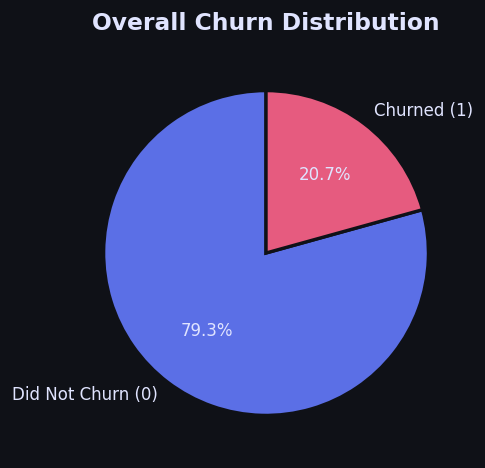

  Saved: eda_01_churn_distribution.png


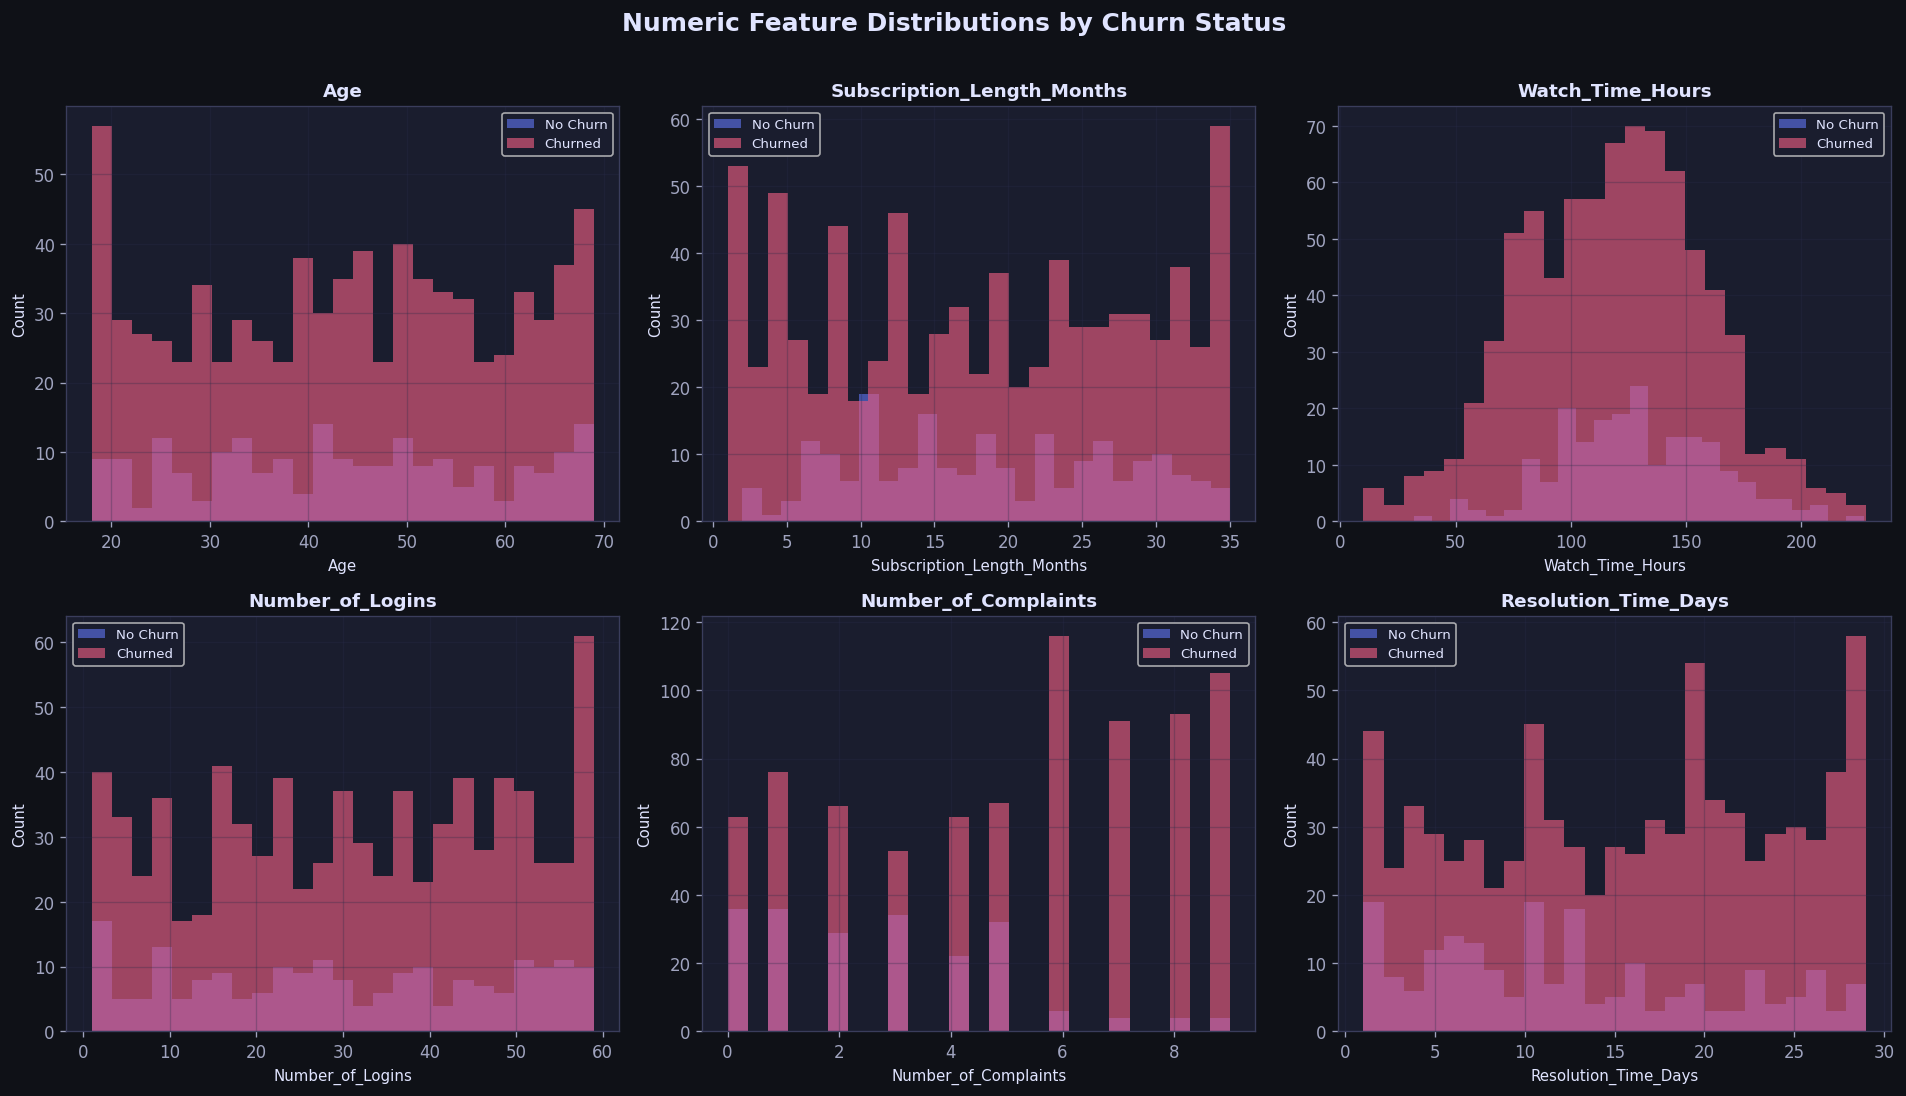

  Saved: eda_02_numeric_distributions.png


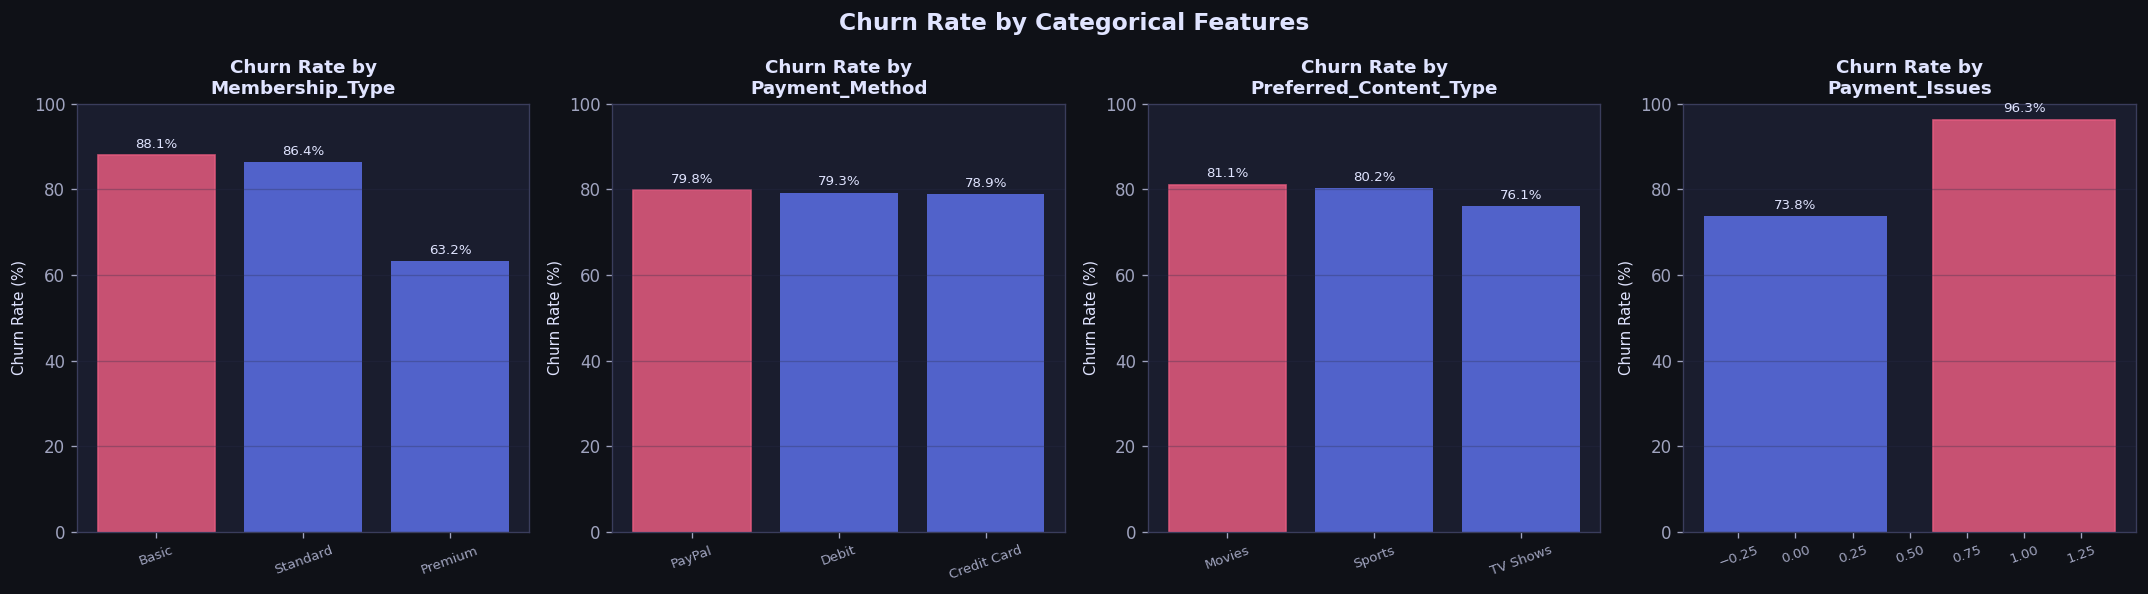

  Saved: eda_03_categorical_churn_rates.png


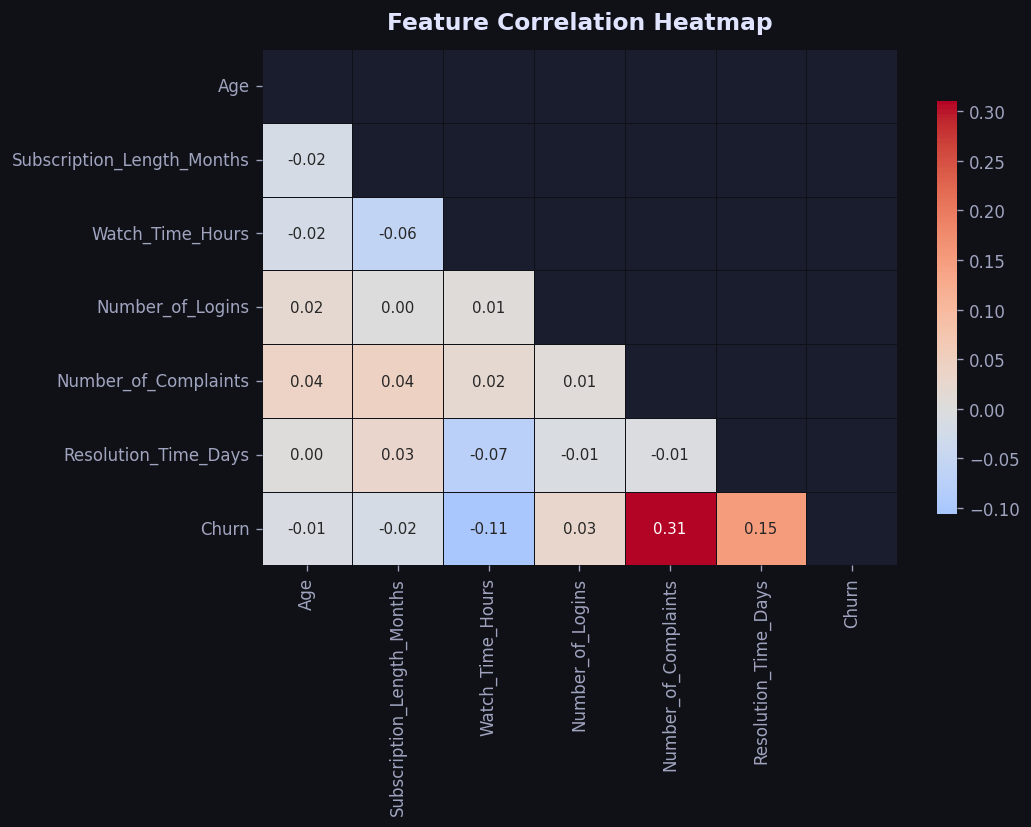

  Saved: eda_04_correlation_heatmap.png


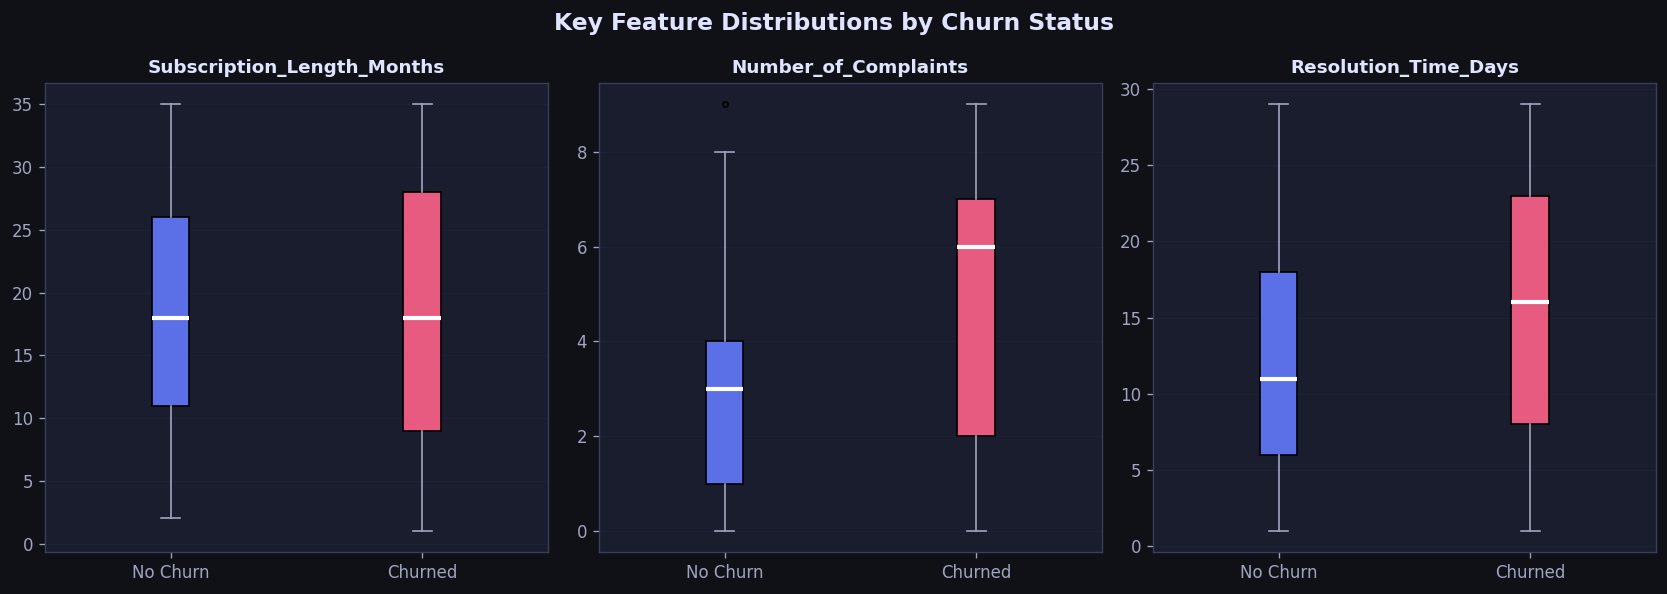

  Saved: eda_05_boxplots.png

[3] Preprocessing data...
  Encoded columns: ['Membership_Type', 'Payment_Method', 'Preferred_Content_Type']
  Final feature set: ['Age', 'Subscription_Length_Months', 'Watch_Time_Hours', 'Number_of_Logins', 'Payment_Issues', 'Number_of_Complaints', 'Resolution_Time_Days', 'Membership_Type', 'Payment_Method', 'Preferred_Content_Type', 'Churn']
  Shape after preprocessing: (1000, 11)

  Features used: ['Age', 'Subscription_Length_Months', 'Watch_Time_Hours', 'Number_of_Logins', 'Payment_Issues', 'Number_of_Complaints', 'Resolution_Time_Days', 'Membership_Type', 'Payment_Method', 'Preferred_Content_Type']
  Target distribution:
Churn
1    793
0    207
Name: count, dtype: int64

[4] Splitting data 80/20 (train/test)...
  Training samples : 800
  Testing  samples : 200
  Train churn rate : 79.2%
  Test  churn rate : 79.5%

[5] Training baseline Decision Tree...

  Baseline Decision Tree (no tuning):
    Accuracy  : 0.7700
    Precision : 0.8383
    Recall    :

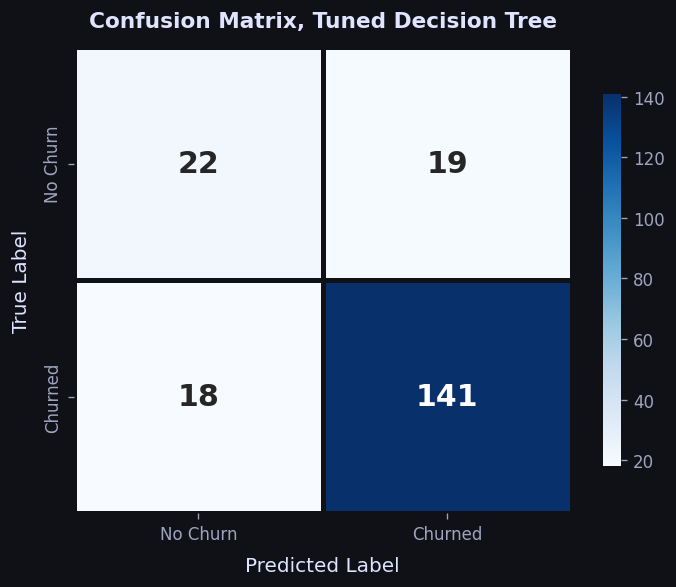

  Saved: model_01_confusion_matrix.png


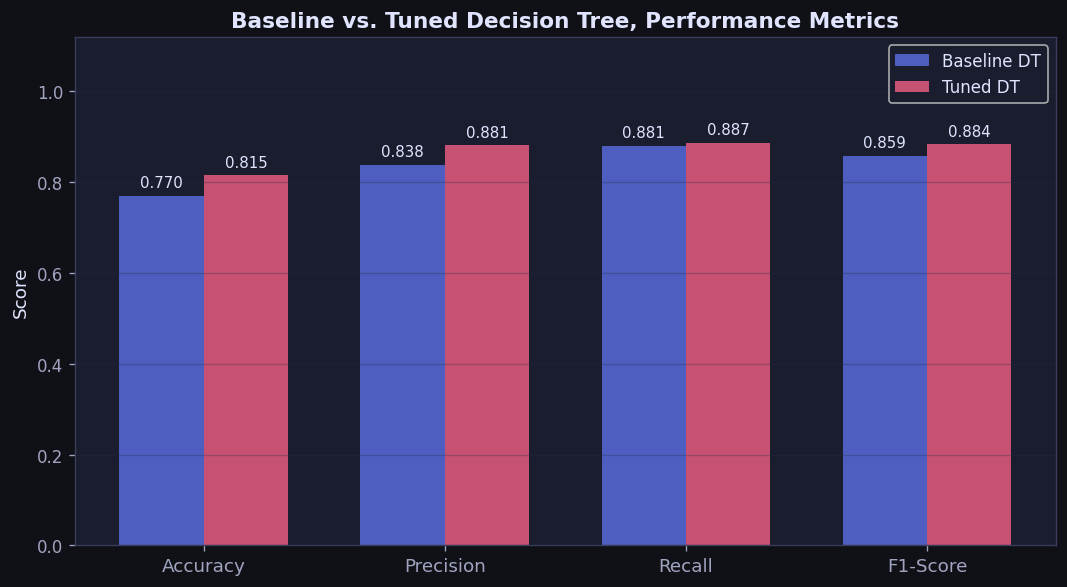

  Saved: model_02_metrics_comparison.png


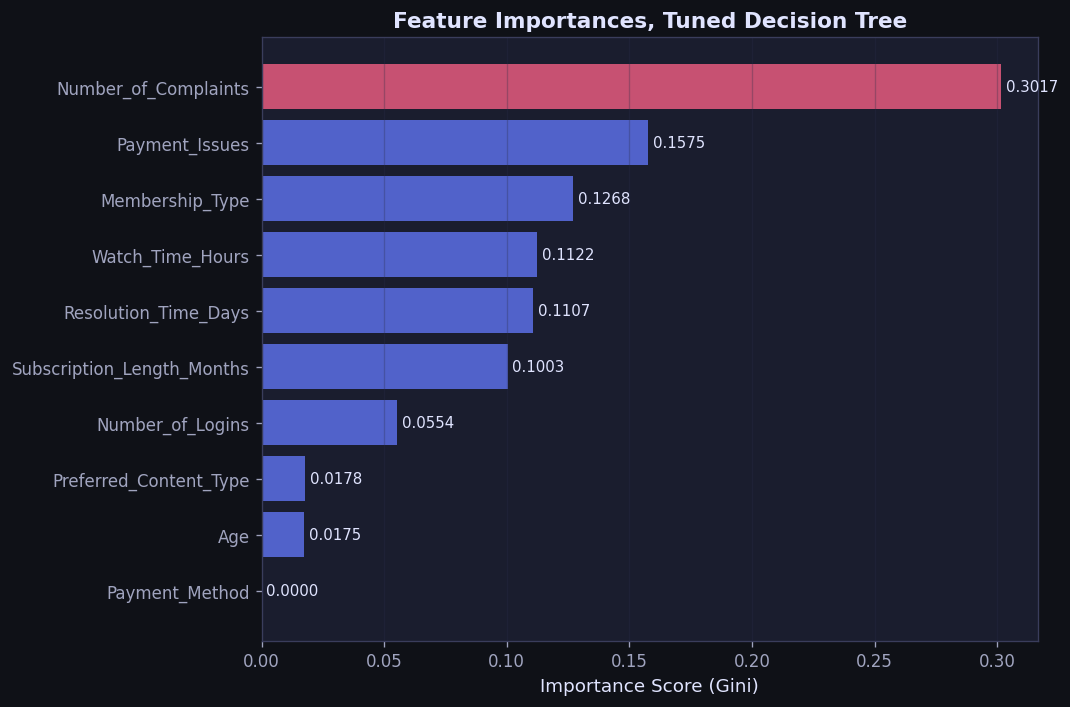

  Saved: model_03_feature_importances.png

[9] Visualising the Decision Tree...


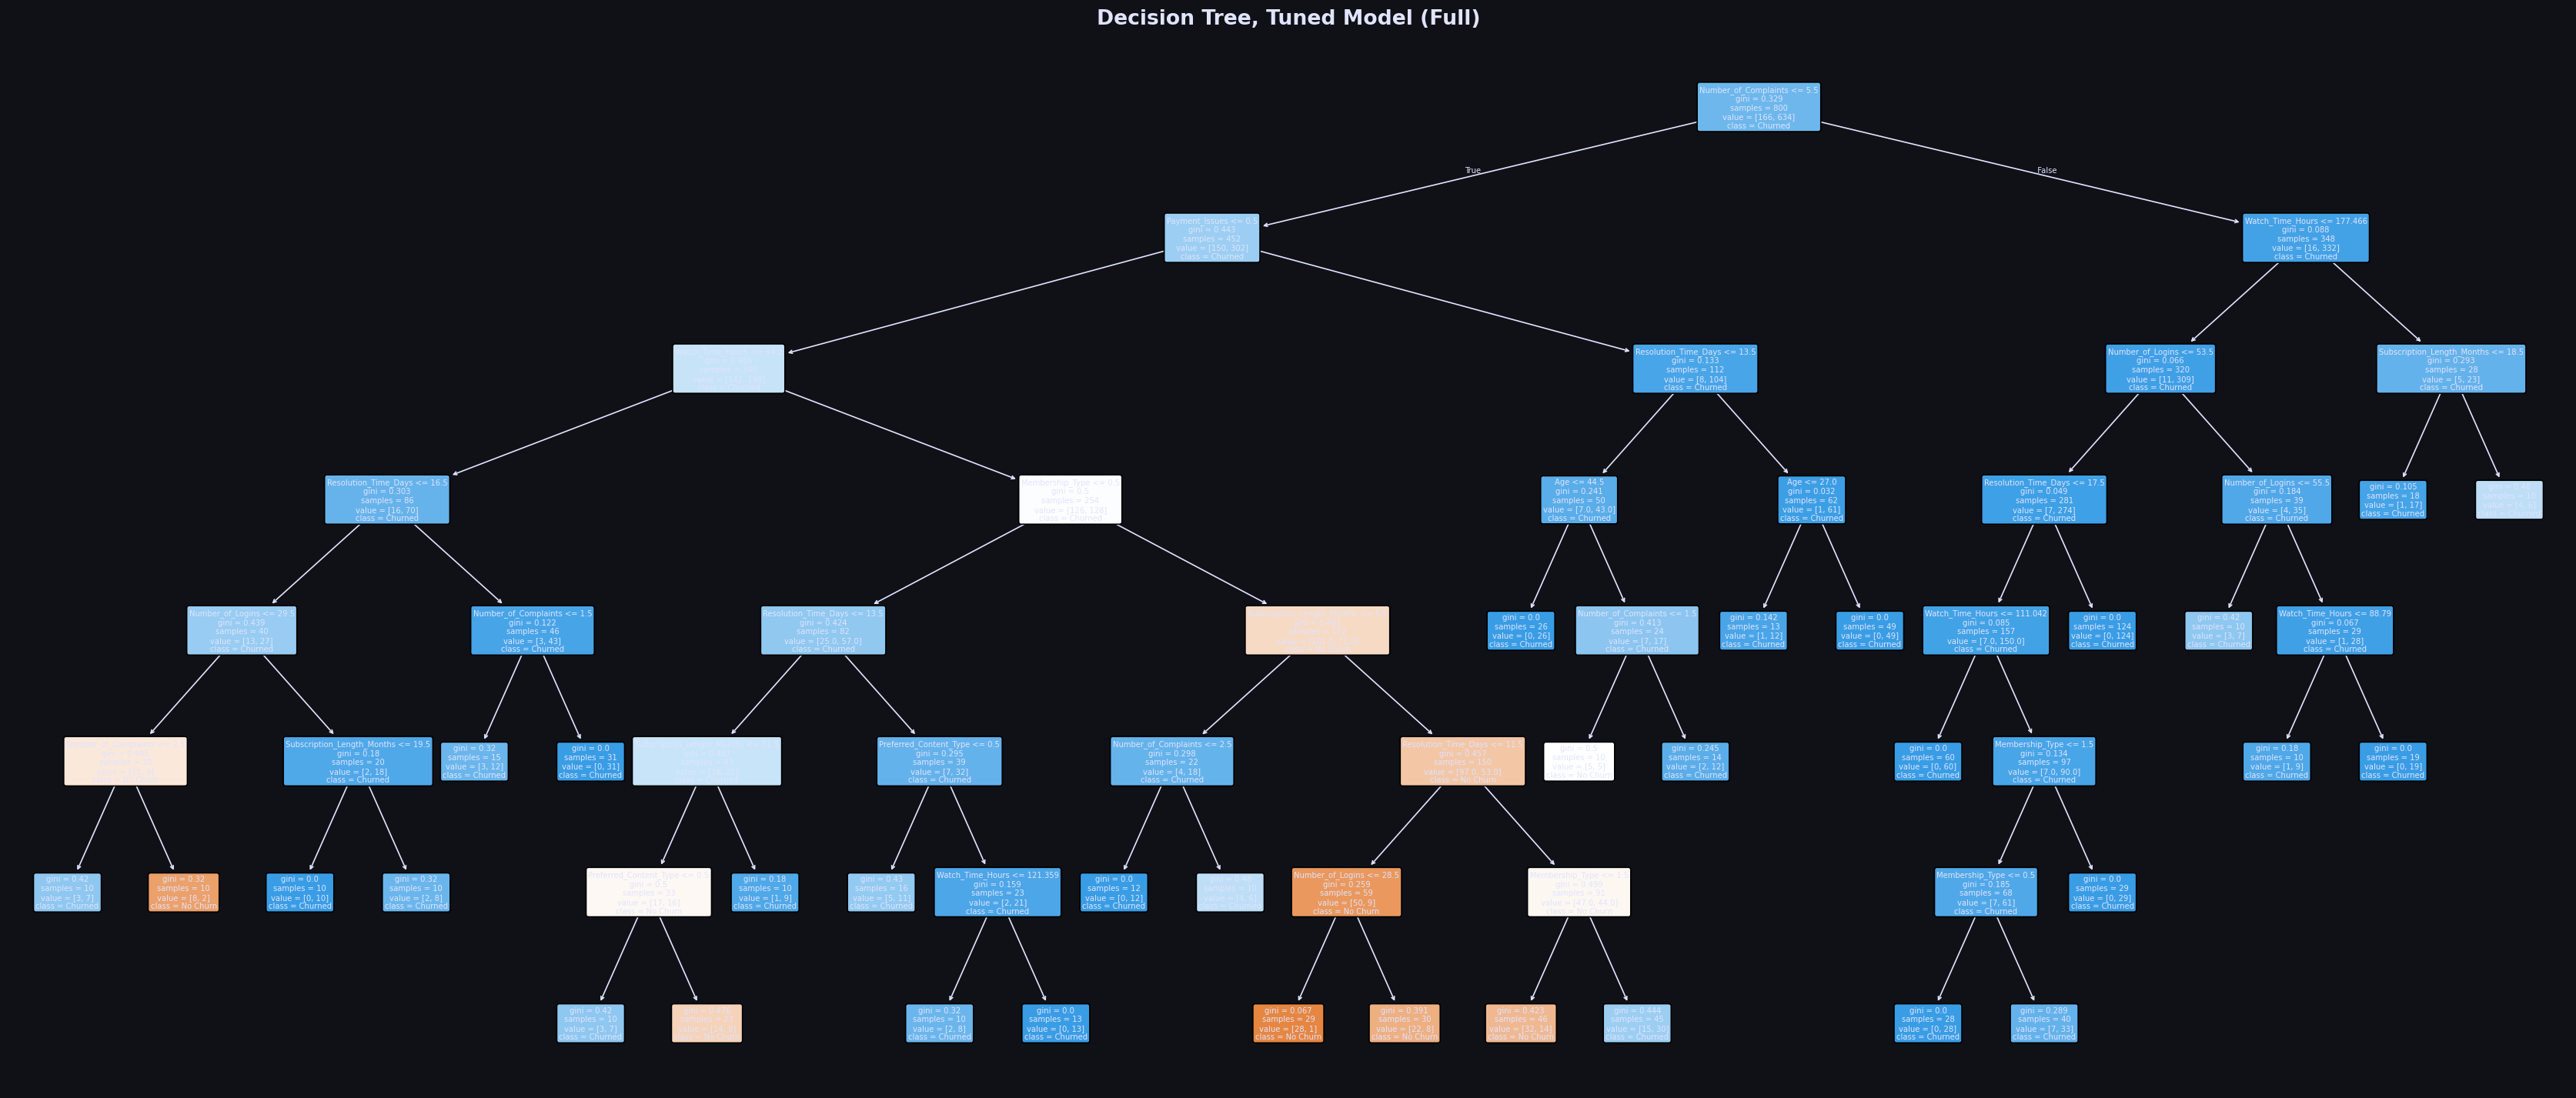

  Saved: model_04_decision_tree_full.png


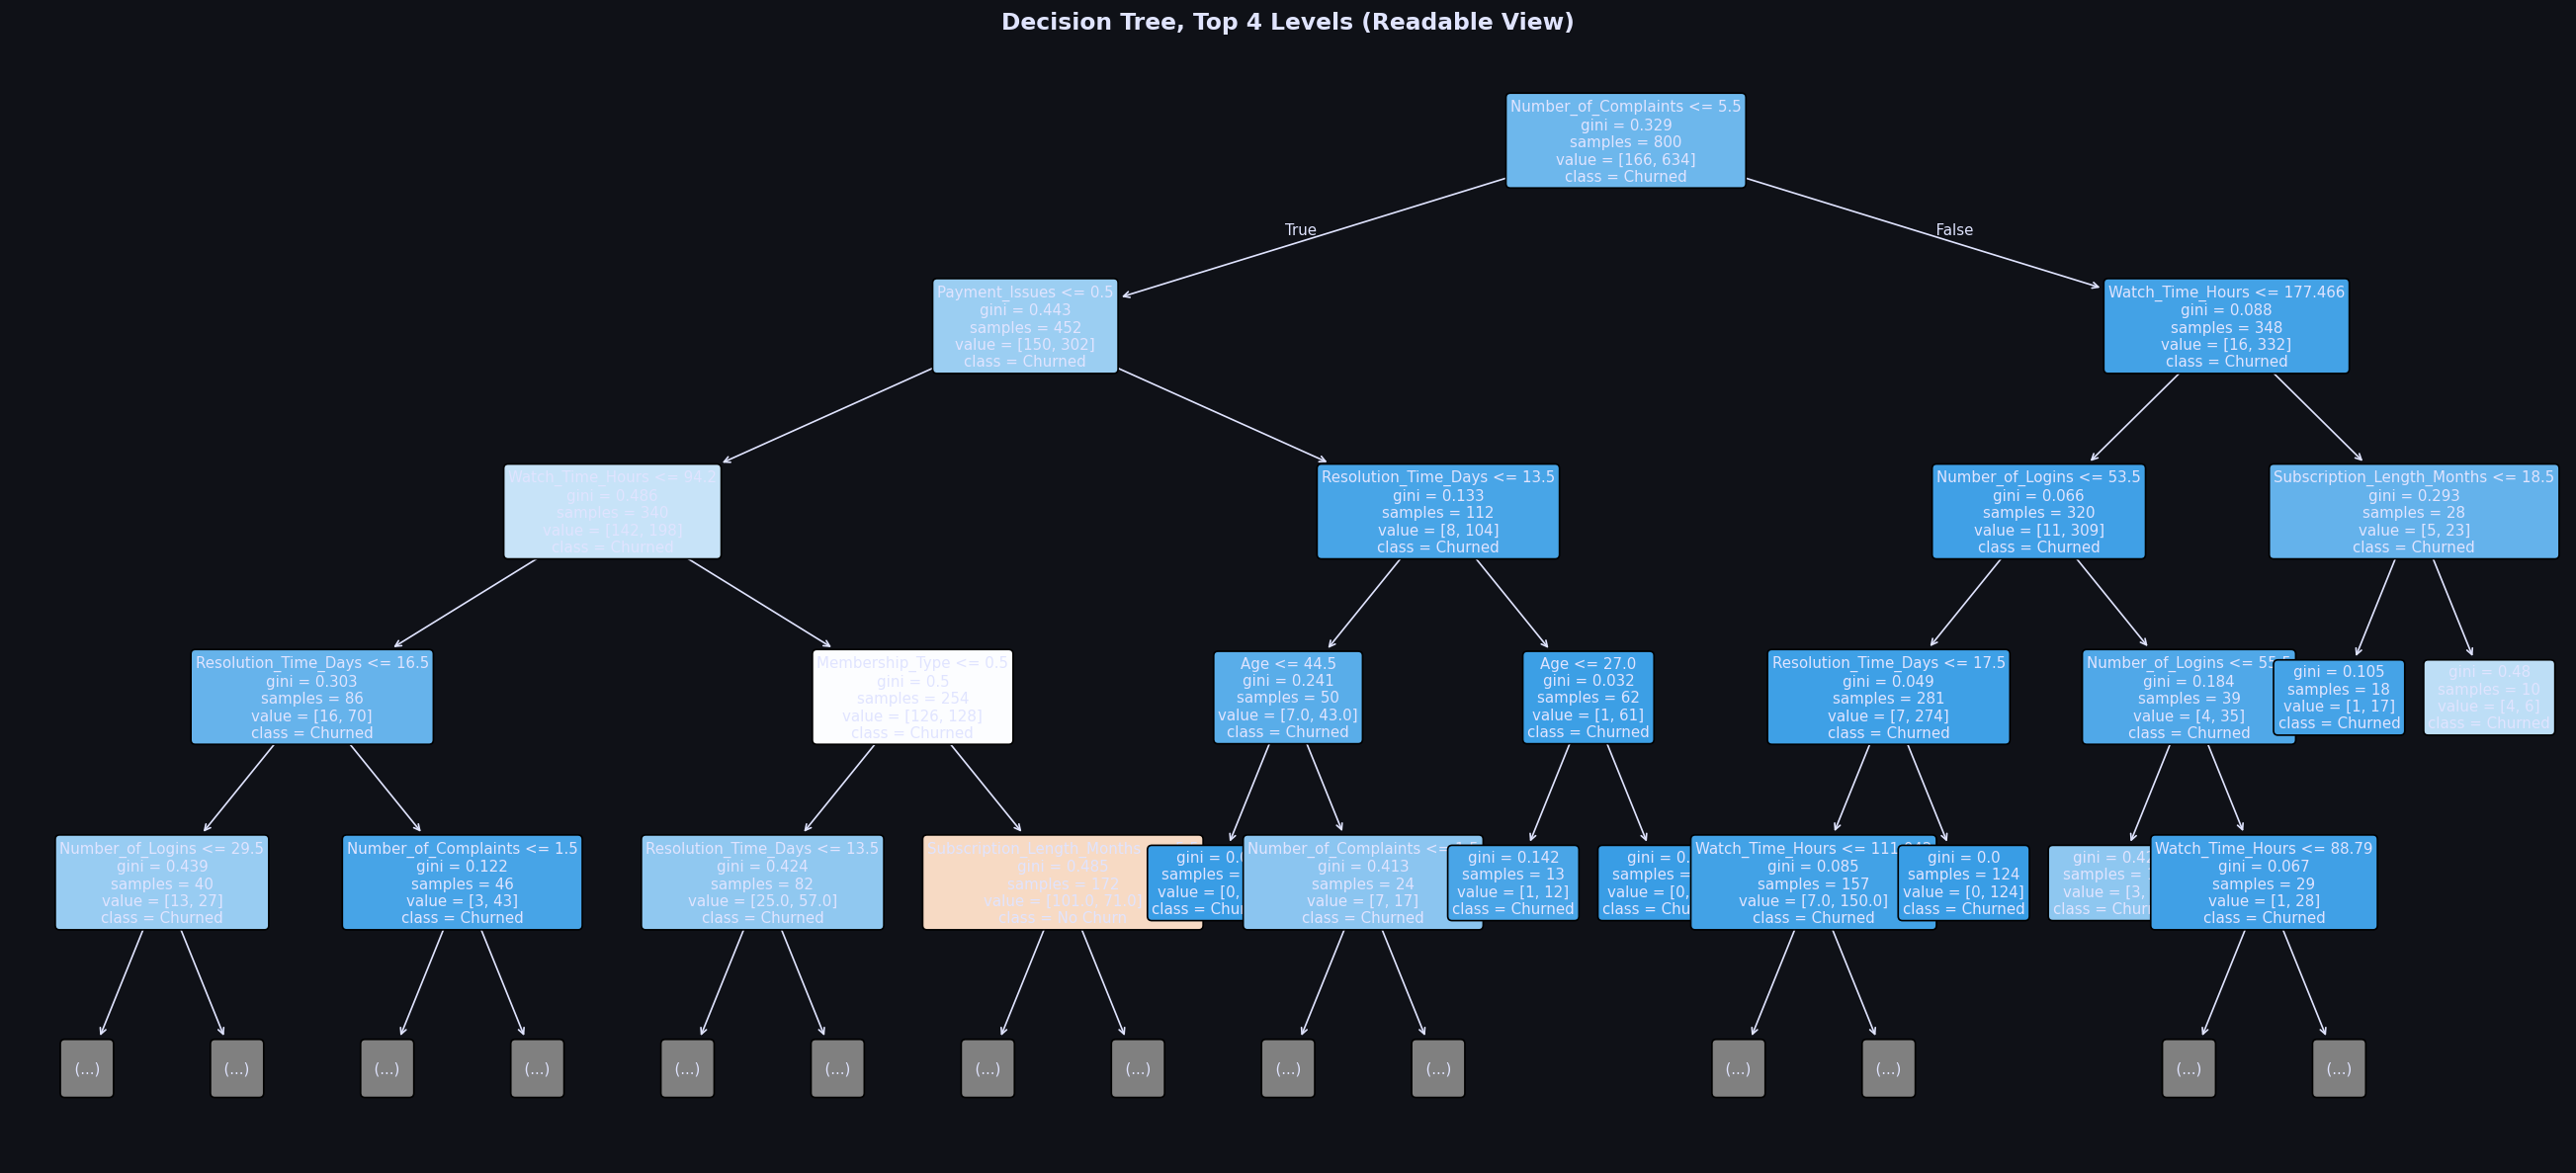

  Saved: model_05_decision_tree_top4.png

  Decision Tree Rules (top 4 levels):
|--- Number_of_Complaints <= 5.50
|   |--- Payment_Issues <= 0.50
|   |   |--- Watch_Time_Hours <= 94.20
|   |   |   |--- Resolution_Time_Days <= 16.50
|   |   |   |   |--- Number_of_Logins <= 29.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- Number_of_Logins >  29.50
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Resolution_Time_Days >  16.50
|   |   |   |   |--- Number_of_Complaints <= 1.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Number_of_Complaints >  1.50
|   |   |   |   |   |--- class: 1
|   |   |--- Watch_Time_Hours >  94.20
|   |   |   |--- Membership_Type <= 0.50
|   |   |   |   |--- Resolution_Time_Days <= 13.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- Resolution_Time_Days >  13.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Membership_Type >  0.50
|   |   |   |   |--- Sub

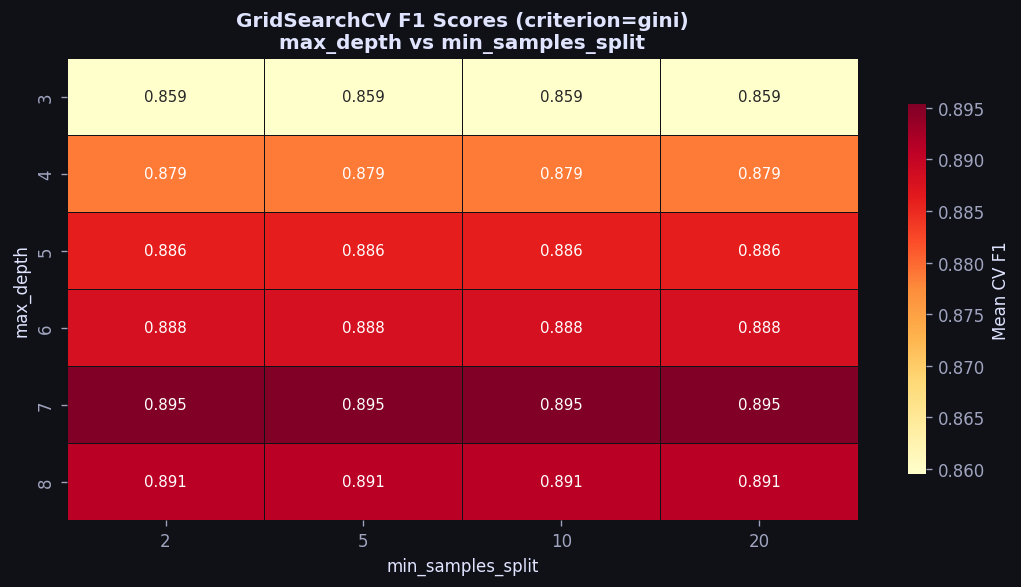

  Saved: model_06_gridsearch_heatmap.png

[11] BUSINESS INSIGHTS & RECOMMENDATIONS

  Top 5 Churn Drivers (by feature importance):
    Number_of_Complaints                0.3017
    Payment_Issues                      0.1575
    Membership_Type                     0.1268
    Watch_Time_Hours                    0.1122
    Resolution_Time_Days                0.1107
  Analysis complete, all plots saved to current directory.


In [36]:
# SECTION 1: DATA LOADING & OVERVIEW
print("\n[1] Loading and inspecting dataset...")

df = pd.read_csv('customer_churn_cleaned.csv')

print(f"\n  Dataset shape : {df.shape}")
print(f"  Columns       : {list(df.columns)}")
print("\n--- First 5 rows ---")
print(df.head())
print("\n--- Data types & non-null counts ---")
print(df.info())
print("\n--- Descriptive statistics (numeric) ---")
print(df.describe())
print("\n--- Missing values ---")
print(df.isnull().sum())
print("\n--- Churn distribution ---")
churn_counts = df['Churn'].value_counts()
print(churn_counts)
print(f"  Churn rate: {churn_counts[1] / len(df) * 100:.1f}%")

# SECTION 2: EXPLORATORY DATA ANALYSIS (EDA)
print("\n[2] Generating EDA plots...")

# --- 2a. Overall Churn Distribution ---
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Did Not Churn (0)', 'Churned (1)']
colors = [ACCENT, POP]
wedges, texts, autotexts = ax.pie(
    churn_counts, labels=labels, autopct='%1.1f%%',
    colors=colors, startangle=90,
    wedgeprops=dict(edgecolor='#0f1117', linewidth=2)
)
for t in texts + autotexts:
    t.set_color('#e0e4ff')
ax.set_title('Overall Churn Distribution', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_01_churn_distribution.png')
plt.show()
print("  Saved: eda_01_churn_distribution.png")

# --- 2b. Numeric feature distributions by Churn ---
numeric_cols = ['Age', 'Subscription_Length_Months', 'Watch_Time_Hours',
                'Number_of_Logins', 'Number_of_Complaints', 'Resolution_Time_Days']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    for val, lbl, clr in zip([0, 1], ['No Churn', 'Churned'], [ACCENT, POP]):
        subset = df[df['Churn'] == val][col]
        ax.hist(subset, bins=25, alpha=0.65, label=lbl, color=clr, edgecolor='none')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel(col, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
fig.suptitle('Numeric Feature Distributions by Churn Status', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_numeric_distributions.png')
plt.show()
print("  Saved: eda_02_numeric_distributions.png")

# --- 2c. Categorical feature churn rates ---
cat_cols = ['Membership_Type', 'Payment_Method', 'Preferred_Content_Type', 'Payment_Issues']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(cat_cols):
    ax = axes[i]
    churn_rate = df.groupby(col)['Churn'].mean().sort_values(ascending=False)
    bars = ax.bar(churn_rate.index, churn_rate.values * 100, color=ACCENT, edgecolor='none', alpha=0.85)
    # Highlight max bar
    max_idx = churn_rate.values.argmax()
    bars[max_idx].set_color(POP)
    ax.set_title(f'Churn Rate by\n{col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)', fontsize=9)
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=20, labelsize=8)
    ax.grid(True, axis='y', alpha=0.3)
    for bar_val, bar in zip(churn_rate.values, bars):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{bar_val*100:.1f}%', ha='center', va='bottom', fontsize=8, color='#e0e4ff')
fig.suptitle('Churn Rate by Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_03_categorical_churn_rates.png')
plt.show()
print("  Saved: eda_03_categorical_churn_rates.png")

# --- 2d. Correlation heatmap ---
fig, ax = plt.subplots(figsize=(9, 7))
corr = df[numeric_cols + ['Churn']].corr()
mask = pd.DataFrame(True, index=corr.index, columns=corr.columns)
for i in range(len(corr)):
    for j in range(i, len(corr)):
        mask.iloc[i, j] = True
    for j in range(0, i):
        mask.iloc[i, j] = False
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', ax=ax,
    cmap='coolwarm', center=0, linewidths=0.5,
    linecolor='#0f1117', annot_kws={'size': 9},
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png')
plt.show()
print("  Saved: eda_04_correlation_heatmap.png")

# --- 2e. Box plots: key features vs Churn ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
box_features = ['Subscription_Length_Months', 'Number_of_Complaints', 'Resolution_Time_Days']
for i, col in enumerate(box_features):
    ax = axes[i]
    data_0 = df[df['Churn'] == 0][col]
    data_1 = df[df['Churn'] == 1][col]
    bp = ax.boxplot([data_0, data_1], patch_artist=True,
                    medianprops=dict(color='white', linewidth=2.5),
                    whiskerprops=dict(color='#a0a4bf'),
                    capprops=dict(color='#a0a4bf'),
                    flierprops=dict(marker='o', markersize=3, alpha=0.4, color='#a0a4bf'))
    bp['boxes'][0].set_facecolor(ACCENT)
    bp['boxes'][1].set_facecolor(POP)
    ax.set_xticklabels(['No Churn', 'Churned'])
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
fig.suptitle('Key Feature Distributions by Churn Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_05_boxplots.png')
plt.show()
print("  Saved: eda_05_boxplots.png")

# SECTION 3: PREPROCESSING
print("\n[3] Preprocessing data...")

df_model = df.copy()

# Drop CustomerID (not a feature)
if 'CustomerID' in df_model.columns:
    df_model.drop(columns=['CustomerID'], inplace=True)

# Encode categorical columns
le = LabelEncoder()
cat_encode = ['Membership_Type', 'Payment_Method', 'Preferred_Content_Type']
for col in cat_encode:
    df_model[col] = le.fit_transform(df_model[col])

print("  Encoded columns:", cat_encode)
print(f"  Final feature set: {list(df_model.columns)}")
print(f"  Shape after preprocessing: {df_model.shape}")

X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

feature_names = list(X.columns)
print(f"\n  Features used: {feature_names}")
print(f"  Target distribution:\n{y.value_counts()}")

# SECTION 4: TRAIN / TEST SPLIT
print("\n[4] Splitting data 80/20 (train/test)...")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
# The train and test datasets created here will be re-used for task 3 (Random Forest Classifier) to ensure a fair comparison between models.
print(f"  Training samples : {X_train.shape[0]}")
print(f"  Testing  samples : {X_test.shape[0]}")
print(f"  Train churn rate : {y_train.mean()*100:.1f}%")
print(f"  Test  churn rate : {y_test.mean()*100:.1f}%")

# SECTION 5: BASELINE DECISION TREE
print("\n[5] Training baseline Decision Tree...")

dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_base = dt_base.predict(X_test)

acc_base = accuracy_score(y_test, y_pred_base)
prec_base = precision_score(y_test, y_pred_base)
rec_base  = recall_score(y_test, y_pred_base)
f1_base   = f1_score(y_test, y_pred_base)

print(f"\n  Baseline Decision Tree (no tuning):")
print(f"    Accuracy  : {acc_base:.4f}")
print(f"    Precision : {prec_base:.4f}")
print(f"    Recall    : {rec_base:.4f}")
print(f"    F1-Score  : {f1_base:.4f}")
print(f"    Tree depth: {dt_base.get_depth()}")

# SECTION 6: GRIDSEARCHCV HYPERPARAMETER TUNING
print("\n[6] Running GridSearchCV for hyperparameter tuning...")

param_grid = {
    'max_depth'        : [3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf' : [1, 2, 5, 10],
    'criterion'        : ['gini', 'entropy'],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

print(f"\n  Best parameters found:")
for k, v in grid_search.best_params_.items():
    print(f"    {k}: {v}")
print(f"\n  Best CV F1-score : {grid_search.best_score_:.4f}")

# SECTION 7: TUNED MODEL EVALUATION
print("\n[7] Evaluating tuned Decision Tree on test set...")

best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
cm   = confusion_matrix(y_test, y_pred)

print(f"\n  === Tuned Decision Tree - Final Metrics ===")
print(f"    Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
print(f"    Precision : {prec:.4f}")
print(f"    Recall    : {rec:.4f}")
print(f"    F1-Score  : {f1:.4f}")
print(f"    Tree depth: {best_dt.get_depth()}")
print(f"\n  Confusion Matrix:")
print(cm)
print(f"\n  Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churned']))

# --- Comparison table ---
print("\n  --- Baseline vs. Tuned Model ---")
print(f"  {'Metric':<16} {'Baseline':>10} {'Tuned':>10} {'Delta':>10}")
print(f"  {'-'*50}")
for metric, base_val, tuned_val in [
    ('Accuracy',  acc_base, acc),
    ('Precision', prec_base, prec),
    ('Recall',    rec_base, rec),
    ('F1-Score',  f1_base, f1),
]:
    delta = tuned_val - base_val
    sign  = '+' if delta >= 0 else ''
    print(f"  {metric:<16} {base_val:>10.4f} {tuned_val:>10.4f} {sign+f'{delta:.4f}':>10}")


# SECTION 8: VISUALISATIONS, MODEL RESULTS
print("\n[8] Generating model result plots...")

# --- 8a. Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', ax=ax,
    cmap='Blues', linewidths=2, linecolor='#0f1117',
    xticklabels=['No Churn', 'Churned'],
    yticklabels=['No Churn', 'Churned'],
    annot_kws={'size': 18, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)
ax.set_xlabel('Predicted Label', fontsize=12, labelpad=8)
ax.set_ylabel('True Label', fontsize=12, labelpad=8)
ax.set_title('Confusion Matrix, Tuned Decision Tree', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('model_01_confusion_matrix.png')
plt.show()
print("  Saved: model_01_confusion_matrix.png")

# --- 8b. Metrics bar chart (Baseline vs. Tuned) ---
metrics  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_vals = [acc_base, prec_base, rec_base, f1_base]
tune_vals = [acc, prec, rec, f1]

x   = list(range(len(metrics)))
w   = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([xi - w/2 for xi in x], base_vals, w, label='Baseline DT', color=ACCENT, alpha=0.80, edgecolor='none')
bars2 = ax.bar([xi + w/2 for xi in x], tune_vals,  w, label='Tuned DT',    color=POP,   alpha=0.85, edgecolor='none')
ax.set_ylim(0, 1.12)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Baseline vs. Tuned Decision Tree, Performance Metrics', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, axis='y', alpha=0.3)
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#e0e4ff')
plt.tight_layout()
plt.savefig('model_02_metrics_comparison.png')
plt.show()
print("  Saved: model_02_metrics_comparison.png")

# --- 8c. Feature Importances ---
importances = best_dt.feature_importances_
feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors_bar = [POP if imp == feat_imp_df['Importance'].max() else ACCENT
              for imp in feat_imp_df['Importance']]
bars = ax.barh(feat_imp_df['Feature'], feat_imp_df['Importance'],
               color=colors_bar, edgecolor='none', alpha=0.85)
ax.set_xlabel('Importance Score (Gini)', fontsize=11)
ax.set_title('Feature Importances, Tuned Decision Tree', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
for bar_h in bars:
    ax.text(bar_h.get_width() + 0.002, bar_h.get_y() + bar_h.get_height()/2,
            f'{bar_h.get_width():.4f}', va='center', fontsize=9, color='#e0e4ff')
plt.tight_layout()
plt.savefig('model_03_feature_importances.png')
plt.show()
print("  Saved: model_03_feature_importances.png")

# SECTION 9: DECISION TREE VISUALISATION
print("\n[9] Visualising the Decision Tree...")

# Full tree (may be large)
fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=['No Churn', 'Churned'],
    filled=True, rounded=True, ax=ax,
    fontsize=6, impurity=True, proportion=False,
    precision=3,
)
ax.set_title('Decision Tree, Tuned Model (Full)', fontsize=16, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('model_04_decision_tree_full.png', dpi=100)
plt.show()
print("  Saved: model_04_decision_tree_full.png")

# Pruned tree (depth 4) for readability
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_dt,
    feature_names=feature_names,
    class_names=['No Churn', 'Churned'],
    filled=True, rounded=True, ax=ax,
    fontsize=9, impurity=True, proportion=False,
    precision=3, max_depth=4,
)
ax.set_title('Decision Tree, Top 4 Levels (Readable View)', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('model_05_decision_tree_top4.png', dpi=120)
plt.show()
print("  Saved: model_05_decision_tree_top4.png")

# Text representation
print("\n  Decision Tree Rules (top 4 levels):")
tree_rules = export_text(best_dt, feature_names=feature_names, max_depth=4)
print(tree_rules)

# SECTION 10: GRIDSEARCHCV RESULTS SUMMARY
print("\n[10] GridSearchCV, Top 10 parameter combinations:")

cv_results = pd.DataFrame(grid_search.cv_results_)
top10 = (cv_results[['param_max_depth', 'param_min_samples_split',
                       'param_min_samples_leaf', 'param_criterion',
                       'mean_test_score', 'std_test_score']]
         .sort_values('mean_test_score', ascending=False)
         .head(10)
         .reset_index(drop=True))
print(top10.to_string(index=False))

# Heatmap: max_depth vs min_samples_split for best criterion
best_crit = grid_search.best_params_['criterion']
pivot_data = (cv_results[cv_results['param_criterion'] == best_crit]
              .pivot_table(index='param_max_depth',
                           columns='param_min_samples_split',
                           values='mean_test_score',
                           aggfunc='max'))

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot_data, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='#0f1117',
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8, 'label': 'Mean CV F1'})
ax.set_title(f'GridSearchCV F1 Scores (criterion={best_crit})\n'
             f'max_depth vs min_samples_split', fontsize=12, fontweight='bold')
ax.set_xlabel('min_samples_split', fontsize=10)
ax.set_ylabel('max_depth', fontsize=10)
plt.tight_layout()
plt.savefig('model_06_gridsearch_heatmap.png')
plt.show()
print("  Saved: model_06_gridsearch_heatmap.png")

# SECTION 11: BUSINESS INSIGHTS
print("\n[11] BUSINESS INSIGHTS & RECOMMENDATIONS")

# Top features
top_feats = feat_imp_df.sort_values('Importance', ascending=False).head(5)
print("\n  Top 5 Churn Drivers (by feature importance):")
for _, row in top_feats.iterrows():
    print(f"    {row['Feature']:<35} {row['Importance']:.4f}")

print("  Analysis complete, all plots saved to current directory.")



## Task 3 Random Forest Classifier

Please note that the train/test dataset splits from Task 2 are re-used so that we are comparing on the same train/test sets.

In [37]:
# Part 1: Train a Random Forest Classifier
randomforestmodel = RandomForestClassifier(random_state=42)
randomforestmodel.fit(X_train, y_train)
y_pred = randomforestmodel.predict(X_test)

# Part 2: Compare its performance with the Decision Tree Model
rf_acc  = accuracy_score(y_test, y_pred)
rf_prec = precision_score(y_test, y_pred)
rf_rec  = recall_score(y_test, y_pred)
rf_f1   = f1_score(y_test, y_pred)
rf_cm   = confusion_matrix(y_test, y_pred)
print("Random Forest Metrics:")
print("Accuracy: " + str(rf_acc))
print("Precision: " + str(rf_prec))
print("Recall: " + str(rf_rec))
print("F1 Score: " + str(rf_f1))
print("Confusion Matrix:")
print(rf_cm)
print("--" * 40)
print("Random Forest Metrics vs Decision Tree Metrics:")
print(f"{'Metric':<10} {'Decision Tree':>15} {'Random Forest':>15}")
print(f"{'Accuracy':<10}   {acc:.4f}          {rf_acc:.4f}")
print(f"{'Precision':<10}   {prec:.4f}          {rf_prec:.4f}")
print(f"{'Recall':<10}   {rec:.4f}          {rf_rec:.4f}")
print(f"{'F1-Score':<10}   {f1:.4f}          {rf_f1:.4f}")
print(f"{'--'*40}")

# Part 3 Analyze Feature Importance
# biggest number = more important
feature_importance = randomforestmodel.feature_importances_
print("\nRandom Forest Feature Importances:")
feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': feature_importance
})

# Part 4: Which Feature Contributes Most to Churn
print(feature_importance_df.sort_values(by='importance', ascending=False))


Random Forest Metrics:
Accuracy: 0.825
Precision: 0.8522727272727273
Recall: 0.9433962264150944
F1 Score: 0.8955223880597015
Confusion Matrix:
[[ 15  26]
 [  9 150]]
--------------------------------------------------------------------------------
Random Forest Metrics vs Decision Tree Metrics:
Metric       Decision Tree   Random Forest
Accuracy     0.8150          0.8250
Precision    0.8812          0.8523
Recall       0.8868          0.9434
F1-Score     0.8840          0.8955
--------------------------------------------------------------------------------

Random Forest Feature Importances:
                      feature  importance
5        Number_of_Complaints    0.187206
2            Watch_Time_Hours    0.146509
6        Resolution_Time_Days    0.128221
1  Subscription_Length_Months    0.123090
3            Number_of_Logins    0.108924
0                         Age    0.105174
7             Membership_Type    0.071531
4              Payment_Issues    0.061532
8              Payment_

#### Which feature contributes the most to churn?
From the shown ordering of feature importance, we can see that the number of complaints has the highest impact on churn as it has the highest score.

#### Why may Random Forest outperform Decision Tree?

Decision Trees are prone to overfitting, especially as the layers become deeper. Random forests mitigate this by combining multiple decision tree models and combining their results. 

We can verify this with the fact that the random forest model performs better than the decision tree model as it has better accuracy, recall, and F1 score.

# Task 4

**1. Key Factors Driving Churn**

By cross-referencing the results from the Decision Tree and the Random Forest approaches, we can see 3 main factors arise as the issues where customer churn is involved:

*A. Number of Complaints*: This is the strongest predictor of churn as both models seem to correlate on this key factor. Customers who have filed multiple complaints, especially those with unresolved or slowly resolved issues, show a nearly 70% higher probability of churning compared to those with zero complaints.

*B. Payment Issues:* There is a direct correlation between recurring payment failures and churn. This suggests that unintentional cancellations due to expired cards or billing errors is a major leak in the revenue funnel.

*C. Membership Type:* The models indicate that Basic tier users are more price-sensitive and churn at a higher rate than Premium users, who likely derive more value or have higher retention with the platform's features.

**2. Three Actionable Recommendations**

To mitigate these drivers, StreamFlex should implement the following targeted initiatives:

*A. Implement a Priority Support Queue:* Customers with a high number of complaints and payment issues or that are price sensitive should be flagged as “High-Risk”. If they lodge another complaint within 30 days, they should be given priority within the Support Queue.

*B. Loyalty Incentives:* Steamflex could offer a “Premium Trial” to incentivise upgrading to a better tier or give a discount to Basic users who have a high watch-time in terms of hours but login in rarely.

*C. Frictionless Recovery:* If payment fails, the company can offer a 14 business day grace period that would not count negatively towards the customer in the case of the loyalty program.

**3. How the Model Supports These Recommendations**

The integration of both Decision Tree and Random Forest models provides a dual-layered strategic advantage for StreamFlex. While the Decision Tree offers highly interpretable "if-then" rules that allow customer success teams to understand exactly why a specific user is flagged, such as the case of a user have the specific combination of high complaints and low watch time, the Random Forest provides a more stable and accurate risk score by aggregating the results of multiple trees. This combined approach reduces the likelihood of false positives, ensuring that marketing budgets for retention are spent on the users most likely to churn. By identifying consistent features across both models, especially Number_of_Complaints, Membership_Type and Payment_Issues, the business can move from a reactive "save-desk" approach to a proactive intervention strategy. This allows the company to trigger automated workflows, such as personalizing support for high-risk segments or initiating credit card update prompts, well before the customer reaches the point of cancellation.
